### PREDICTING HEART DISEASE

In [1]:
import pandas as pd
df = pd.read_csv("heart-disease.csv")
df.shape

(303, 14)

In [2]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


How many classes in target labels..

In [4]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

Visualize moree!!!

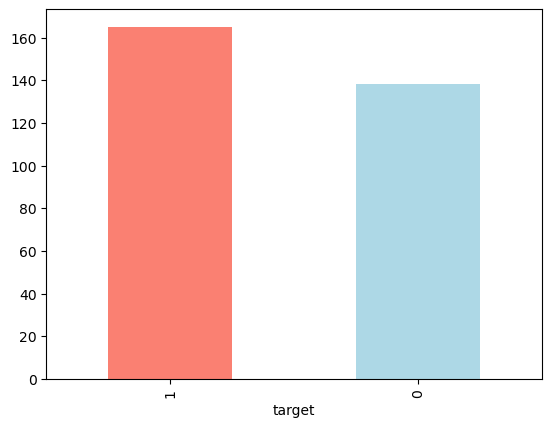

In [5]:
df["target"].value_counts().plot(kind="bar", color = ["salmon", "lightblue"]);

For finding the information of dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


If there are any missing values

In [7]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

No Missing values

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Heart Disease Frequency based on sex
> 1 : Male, 0 : Female

In [9]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

Compare it with target column

In [10]:
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


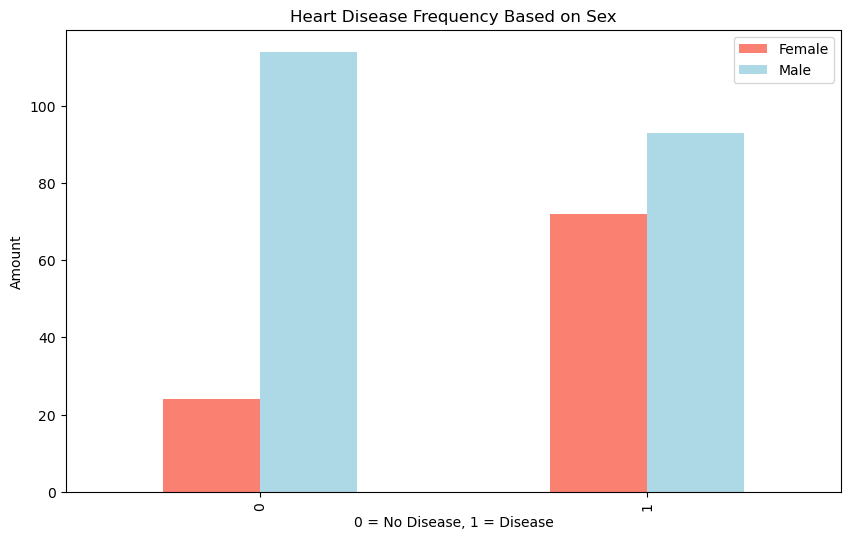

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
# Create a plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10,6),
                                    color=["salmon","lightblue"])
plt.title("Heart Disease Frequency Based on Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"]);

We will see heart rate once

In [12]:
df.thalach.value_counts()

thalach
162    11
160     9
163     9
152     8
173     8
       ..
202     1
184     1
121     1
192     1
90      1
Name: count, Length: 91, dtype: int64

## Age vs Max heart rate 

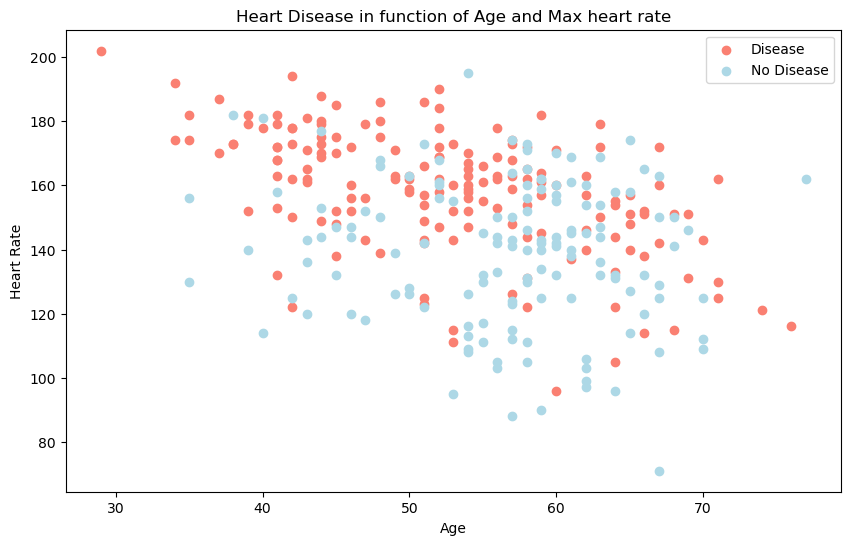

In [13]:
# create another fig
plt.figure(figsize=(10,6))

# Scatter the positive samples
plt.scatter(df.age[df.target == 1],
            df.thalach[df.target == 1],
            c = "salmon")

# scatter negative samples
plt.scatter(df.age[df.target == 0],
            df.thalach[df.target == 0],
            c = "lightblue")

plt.title("Heart Disease in function of Age and Max heart rate")
plt.xlabel("Age")
plt.ylabel("Heart Rate")
plt.legend(["Disease", "No Disease"]);

<Axes: ylabel='Frequency'>

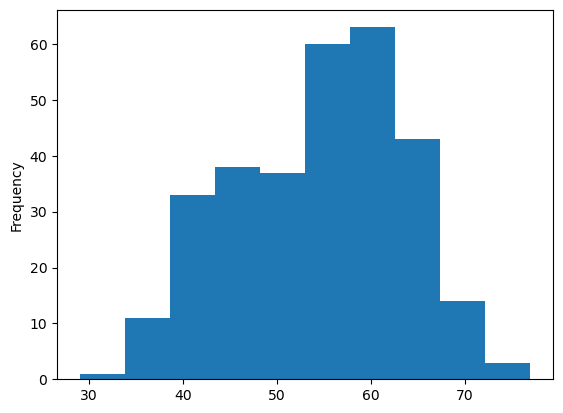

In [14]:
# Check distribution of age column in histogram
df.age.plot.hist()

## Heart Disease Frequency per chest pain

In [15]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


We'll make it more visuall!!

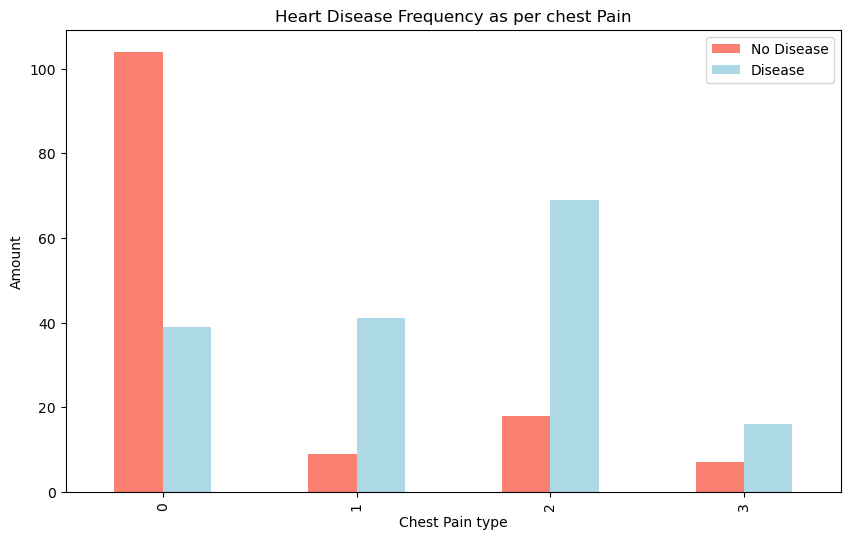

In [16]:
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   figsize=(10,6),
                                   color=["salmon","lightblue"])

plt.title("Heart Disease Frequency as per chest Pain")
plt.xlabel("Chest Pain type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"]);

Now lets make a correlation matrix

In [17]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


Lets make the correlation more visuall!!

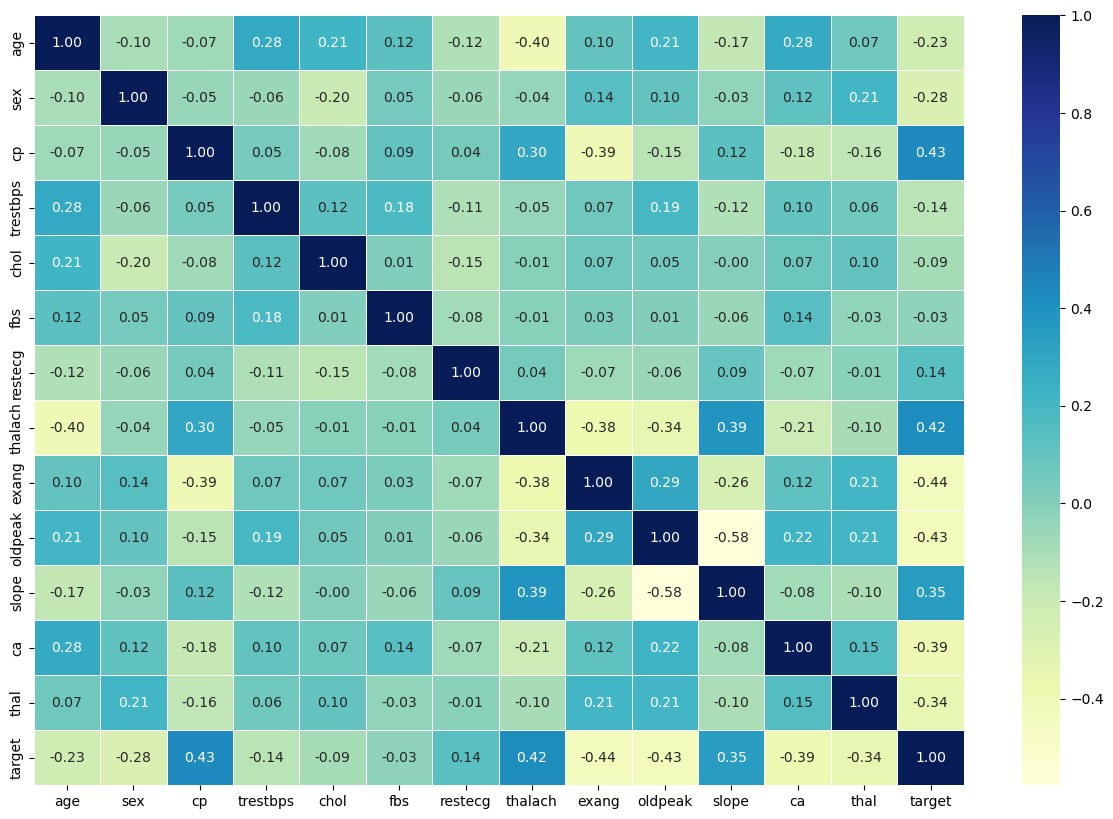

In [18]:
import seaborn as sns
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidth=0.5,
                 fmt=".2f",
                 cmap="YlGnBu")

## Now we'll do the splitting and finding the right model for our data

In [19]:
# split the data
X = df.drop("target", axis=1)
Y = df["target"]

Let's see the data we had split

In [20]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [21]:
Y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

Now we'll split into train and test

In [22]:
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)

X_train,X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)

Now the data is splitted into 80 and 20. We'll see our data once

In [23]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [24]:
Y_train

132    1
202    0
196    0
75     1
176    0
      ..
188    0
71     1
106    1
270    0
102    1
Name: target, Length: 242, dtype: int64

In [25]:
Y_train.shape

(242,)

In [26]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140,254,0,0,146,0,2.0,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
193,60,1,0,145,282,0,0,142,1,2.8,1,2,3


In [27]:
Y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

In [28]:
Y_test.shape

(61,)

Now we'll import the Algorithms

In [29]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [54]:
models = {"Linear SVC":LinearSVC(dual="auto",max_iter=10000),
          "LogisticRegression":LogisticRegression(max_iter=10000),
          "KNN":KNeighborsClassifier(),
          "Random Forest":RandomForestClassifier()}

def fit_and_score(models, X, Y):
    """
    Fit and Evaluate the models
    """
    np.random.seed(42)
    model_score = {}
    for name, model in models.items():
        model.fit(X, Y)
        model_score[name] = model.score(X, Y)
    return model_score

In [55]:
model_scores = fit_and_score(models=models, X=X_train, Y=Y_train)
model_scores

{'Linear SVC': 0.8553719008264463,
 'LogisticRegression': 0.8636363636363636,
 'KNN': 0.7603305785123967,
 'Random Forest': 1.0}

Check for test set

In [56]:
model_scores1 = fit_and_score(models=models, X=X_test, Y=Y_test)
model_scores1

{'Linear SVC': 0.9180327868852459,
 'LogisticRegression': 0.9344262295081968,
 'KNN': 0.819672131147541,
 'Random Forest': 1.0}

## Evaluation of model's performance using different metrics

**For test set**

In [39]:
# Import the different metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [69]:
def score(model,Y):
    np.random.seed(42)
    model.fit(X_train, Y_train)
    y = model.predict(X_test)
    results = {"Accuracy": accuracy_score(Y,y),
                "Precision": precision_score(Y,y),
                "Recall": recall_score(Y,y),
                "F1 score": f1_score(Y,y)
                }
    return results

In [97]:
def visualize(model,Y):
    np.random.seed(42)
    model.fit(X_train, Y_train)
    y = model.predict(X_test)
    cm = confusion_matrix(Y,y)
    confusion_matrix_df = pd.DataFrame(cm,index=["Actual " + str(x) for x in Y_test.unique()],
columns=["Predicted " + str(x) for x in Y_test.unique()])
    classification_report_str = classification_report(Y,y,output_dict=True)
    return confusion_matrix_df, classification_report_str

**LINEAR SVC**

In [70]:
score(model=LinearSVC(dual="auto",max_iter=10000),Y=Y_test)

{'Accuracy': 0.8688524590163934,
 'Precision': 0.875,
 'Recall': 0.875,
 'F1 score': 0.875}

In [98]:
visualize(model = LinearSVC(dual="auto",max_iter=10000),Y=Y_test)

(          Predicted 0  Predicted 1
 Actual 0           25            4
 Actual 1            4           28,
 {'0': {'precision': 0.8620689655172413,
   'recall': 0.8620689655172413,
   'f1-score': 0.8620689655172413,
   'support': 29.0},
  '1': {'precision': 0.875,
   'recall': 0.875,
   'f1-score': 0.875,
   'support': 32.0},
  'accuracy': 0.8688524590163934,
  'macro avg': {'precision': 0.8685344827586207,
   'recall': 0.8685344827586207,
   'f1-score': 0.8685344827586207,
   'support': 61.0},
  'weighted avg': {'precision': 0.8688524590163934,
   'recall': 0.8688524590163934,
   'f1-score': 0.8688524590163934,
   'support': 61.0}})

**LOGISTIC REGRESSION**

In [79]:
score(model=LogisticRegression(max_iter=10000),Y=Y_test)

{'Accuracy': 0.8852459016393442,
 'Precision': 0.8787878787878788,
 'Recall': 0.90625,
 'F1 score': 0.8923076923076924}

In [99]:
visualize(model=LogisticRegression(max_iter=10000),Y=Y_test)

(          Predicted 0  Predicted 1
 Actual 0           25            4
 Actual 1            3           29,
 {'0': {'precision': 0.8928571428571429,
   'recall': 0.8620689655172413,
   'f1-score': 0.8771929824561403,
   'support': 29.0},
  '1': {'precision': 0.8787878787878788,
   'recall': 0.90625,
   'f1-score': 0.8923076923076924,
   'support': 32.0},
  'accuracy': 0.8852459016393442,
  'macro avg': {'precision': 0.8858225108225108,
   'recall': 0.8841594827586207,
   'f1-score': 0.8847503373819163,
   'support': 61.0},
  'weighted avg': {'precision': 0.8854765453126109,
   'recall': 0.8852459016393442,
   'f1-score': 0.8851220105749872,
   'support': 61.0}})

**KNN**

In [82]:
score(model=KNeighborsClassifier(),Y=Y_test)

{'Accuracy': 0.6885245901639344,
 'Precision': 0.6857142857142857,
 'Recall': 0.75,
 'F1 score': 0.7164179104477612}

In [100]:
visualize(model=KNeighborsClassifier(),Y=Y_test)

(          Predicted 0  Predicted 1
 Actual 0           18           11
 Actual 1            8           24,
 {'0': {'precision': 0.6923076923076923,
   'recall': 0.6206896551724138,
   'f1-score': 0.6545454545454545,
   'support': 29.0},
  '1': {'precision': 0.6857142857142857,
   'recall': 0.75,
   'f1-score': 0.7164179104477612,
   'support': 32.0},
  'accuracy': 0.6885245901639344,
  'macro avg': {'precision': 0.689010989010989,
   'recall': 0.6853448275862069,
   'f1-score': 0.6854816824966079,
   'support': 61.0},
  'weighted avg': {'precision': 0.6888488560619708,
   'recall': 0.6885245901639344,
   'f1-score': 0.6870031363302711,
   'support': 61.0}})

**RANDOM FOREST**`

In [84]:
score(model=RandomForestClassifier(),Y=Y_test)

{'Accuracy': 0.8360655737704918,
 'Precision': 0.84375,
 'Recall': 0.84375,
 'F1 score': 0.84375}

In [101]:
visualize(model=RandomForestClassifier(),Y=Y_test)

(          Predicted 0  Predicted 1
 Actual 0           24            5
 Actual 1            5           27,
 {'0': {'precision': 0.8275862068965517,
   'recall': 0.8275862068965517,
   'f1-score': 0.8275862068965517,
   'support': 29.0},
  '1': {'precision': 0.84375,
   'recall': 0.84375,
   'f1-score': 0.84375,
   'support': 32.0},
  'accuracy': 0.8360655737704918,
  'macro avg': {'precision': 0.8356681034482758,
   'recall': 0.8356681034482758,
   'f1-score': 0.8356681034482758,
   'support': 61.0},
  'weighted avg': {'precision': 0.8360655737704918,
   'recall': 0.8360655737704918,
   'f1-score': 0.8360655737704918,
   'support': 61.0}})